# Load UinWind

In [11]:

import numpy as np
import onnxruntime as ort
import pandas as pd
from datetime import datetime, timedelta
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

onnx_path = "universal_predictor.onnx"
session = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])

# Load Data

In [10]:
def load_from_pkl(filename):
    with open(filename, 'rb') as file:
        data = pickle.load(file)
    return data

In [4]:
# Normal
TestDataDemo1 = load_from_pkl('TestDataDemo1.pkl')
Nwp1, Time1, History_Nwp_Power1, Power1, WFid1 = TestDataDemo1 

# Long-Lasting Low Wind Power Events & Large Wind Power Ramp Events
TestDataDemo2 = load_from_pkl('TestDataDemo2.pkl')
Nwp2, Time2, History_Nwp_Power2, Power2, WFid2 = TestDataDemo2

In [220]:
# Data shapes:
# Nwp1: [samples, time, 144] = 4 variables × 6 × 6 grid
# Time1: [samples, time, 3] = month, day, hour
# Power1: [samples, time, 1] = normalized power
# History_Nwp_Power1: [samples, days, time, 148] = NWP(144)+Time(3)+Power(1)
# WFid1: [samples, time, 1] = wind farm ID

print("Nwp1 shape:", Nwp1.shape)                  # (5, 96, 144)
print("Time1 shape:", Time1.shape)                # (5, 96, 3) -> month, day, hour
print("History_Nwp_Power1 shape:", History_Nwp_Power1.shape)  # (5, 7, 96, 148)
print("Power1 shape:", Power1.shape)              # (5, 96, 1) normalized power
print("WFid1 shape:", WFid1.shape)                # (5, 96, 1) wind farm ID

Nwp1 shape: (5, 96, 144)
Time1 shape: (5, 96, 3)
History_Nwp_Power1 shape: (5, 7, 96, 148)
Power1 shape: (5, 96, 1)
WFid1 shape: (5, 96, 1)


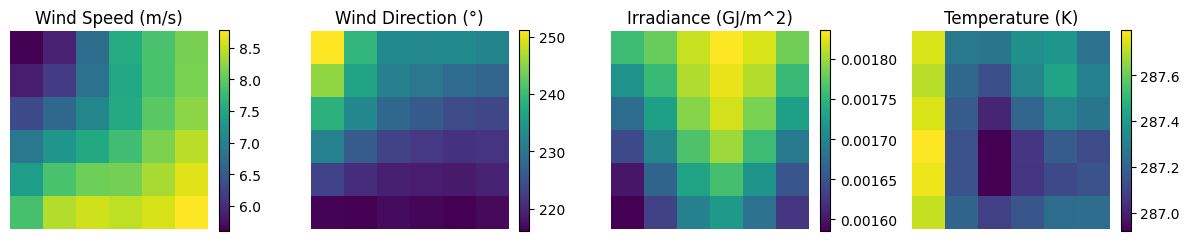

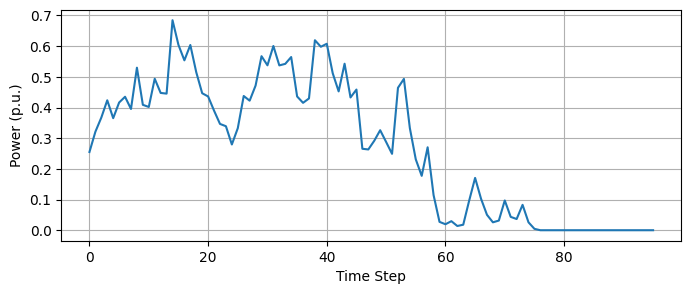

: 

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# NWP grid
# Nwp1 shape: [B, T, 144]
# 144 = 4 variables × (6×6 grid)

sample = 0
time_id = 0

nwp = Nwp1[sample, time_id].reshape(4, 6, 6)

var_names = [
    "Wind Speed (m/s)",
    "Wind Direction (°)",
    "Irradiance (GJ/m^2)",
    "Temperature (K)"
]

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

for i in range(4):
    im = axes[i].imshow(nwp[i], cmap="viridis")
    axes[i].set_title(var_names[i])
    axes[i].axis("off")
    plt.colorbar(im, ax=axes[i], fraction=0.046)

plt.tight_layout()
plt.show()


# Power1 shape: [B, T, 1]
power = Power1[sample, :, 0]

plt.figure(figsize=(8, 3))
plt.plot(power)
plt.xlabel("Time Step")
plt.ylabel("Power (p.u.)")
plt.grid(True)
plt.show()

# Power Forecasting

## Normal

In [6]:
batch_nwp = Nwp1.astype(np.float32)      # (5, 96, 144)
batch_time = Time1.astype(np.float32)    # (5, 96, 3)
batch_his = History_Nwp_Power1.astype(np.float32)      # (5, 7, 96, 148)

inputs = {
    "batch_nwp": batch_nwp,
    "batch_time": batch_time,
    "batch_his": batch_his,
}

# 3. Predict
ForecastingResults1 = session.run(["y_pred"], inputs)[0]

print(ForecastingResults1.shape)

(5, 96, 1)


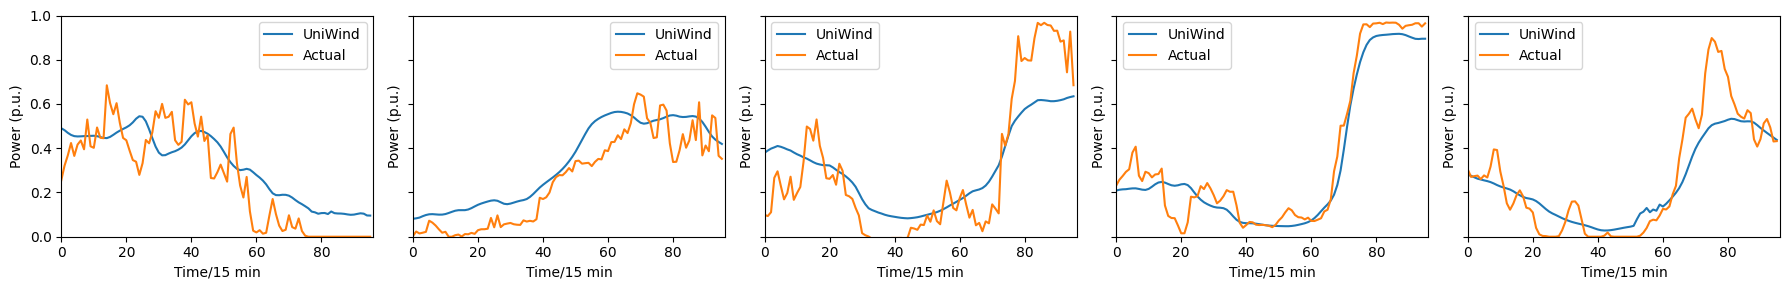

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1行5列，一共5个子图
fig, axes = plt.subplots(1, 5, figsize=(18, 3), sharex=True, sharey=True)
axes = axes.flatten()

# 用来保存每个子图的指标
metrics = []

for i in range(5):
    y_pred = ForecastingResults1[i, :, 0]
    y_true = Power1[i, :, 0]

    # 绘图
    axes[i].plot(y_pred, label='UniWind')
    axes[i].plot(y_true, label='Actual')
    axes[i].set_ylim(0, 1)
    axes[i].set_xlim(0, 96)
    axes[i].set_xlabel('Time/15 min')
    axes[i].set_ylabel('Power (p.u.)')
    # axes[i].set_title(f'Subplot {i+1}')
    axes[i].legend()

    # ===== 计算误差指标 =====
    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
    mae = np.mean(np.abs(y_pred - y_true))

    value_range = 1

    # 防止分母为 0
    if value_range == 0:
        nrmse = np.nan
        nmae = np.nan
        acc_1_nrmse = np.nan
        acc_1_nmae = np.nan
    else:
        nrmse = rmse / value_range
        nmae = mae / value_range
        acc_1_nrmse = 1 - nrmse
        acc_1_nmae = 1 - nmae

    metrics.append({
        'Subplot': i + 1,
        'NRMSE': nrmse,
        'NMAE': nmae,
        '1-NRMSE': acc_1_nrmse,
        '1-NMAE': acc_1_nmae
    })

plt.tight_layout()
plt.show()

## Long-Lasting Low Wind Power Events & Large Wind Power Ramp Events

In [8]:
batch_nwp = Nwp2.astype(np.float32)      # (5, 96, 144)
batch_time = Time2.astype(np.float32)    # (5, 96, 3)
batch_his = History_Nwp_Power2.astype(np.float32)      # (5, 7, 96, 148)

inputs = {
    "batch_nwp": batch_nwp,
    "batch_time": batch_time,
    "batch_his": batch_his,
}

# 3. Predict
ForecastingResults2 = session.run(["y_pred"], inputs)[0]

print(ForecastingResults2.shape)

(6, 96, 1)


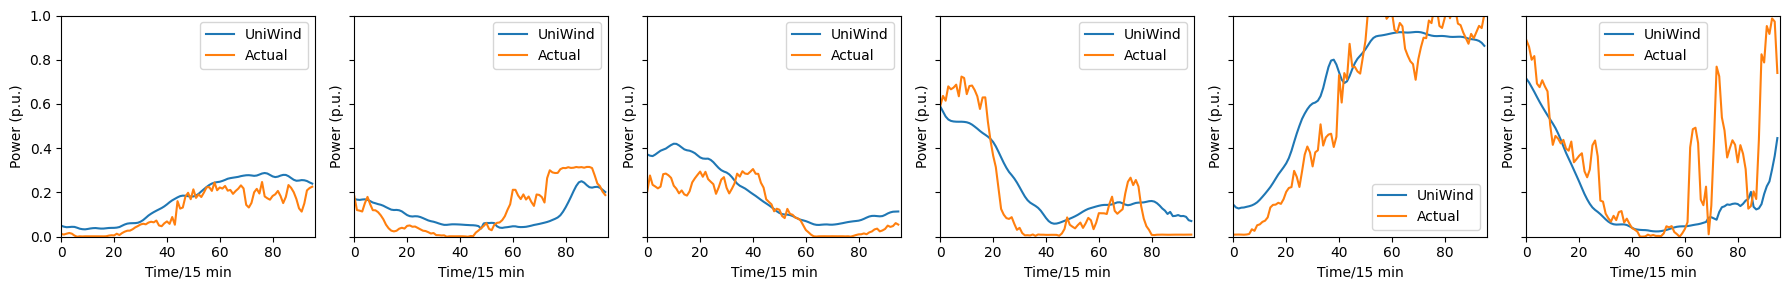

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1行5列，一共5个子图
fig, axes = plt.subplots(1, 6, figsize=(18, 3), sharex=True, sharey=True)
axes = axes.flatten()

# 用来保存每个子图的指标
metrics = []

for i in range(6):
    y_pred = ForecastingResults2[i, :, 0]
    y_true = Power2[i, :, 0]

    # 绘图
    axes[i].plot(y_pred, label='UniWind')
    axes[i].plot(y_true, label='Actual')
    axes[i].set_ylim(0, 1)
    axes[i].set_xlim(0, 96)
    axes[i].set_xlabel('Time/15 min')
    axes[i].set_ylabel('Power (p.u.)')
    # axes[i].set_title(f'Subplot {i+1}')
    axes[i].legend()

    # ===== 计算误差指标 =====
    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
    mae = np.mean(np.abs(y_pred - y_true))

    value_range = 1

    # 防止分母为 0
    if value_range == 0:
        nrmse = np.nan
        nmae = np.nan
        acc_1_nrmse = np.nan
        acc_1_nmae = np.nan
    else:
        nrmse = rmse / value_range
        nmae = mae / value_range
        acc_1_nrmse = 1 - nrmse
        acc_1_nmae = 1 - nmae

    metrics.append({
        'Subplot': i + 1,
        'NRMSE': nrmse,
        'NMAE': nmae,
        '1-NRMSE': acc_1_nrmse,
        '1-NMAE': acc_1_nmae
    })

plt.tight_layout()
plt.show()